# Notebook Eksperimen Tugas Akhir 2

### **Melihat Perilaku Dataset**

#### Import Libraries

In [22]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from statsmodels.tsa.stattools import adfuller

np.random.seed(10122097)

#### Import Dataset to Notebook

In [ ]:
train = pd.read_csv("../datasets/train.csv", parse_dates=['date'])
test = pd.read_csv("../datasets/test.csv", parse_dates=['date'])
oil = pd.read_csv("../datasets/oil.csv", parse_dates=['date'])
holidays = pd.read_csv("../datasets/holidays_events.csv", parse_dates=['date'])
stores = pd.read_csv("../datasets/stores.csv")
transactions = pd.read_csv("../datasets/transactions.csv", parse_dates=['date'])

In [24]:
stores

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15


#### Type & Cluster Counting

<Axes: title={'center': 'Counting Type'}, xlabel='type'>

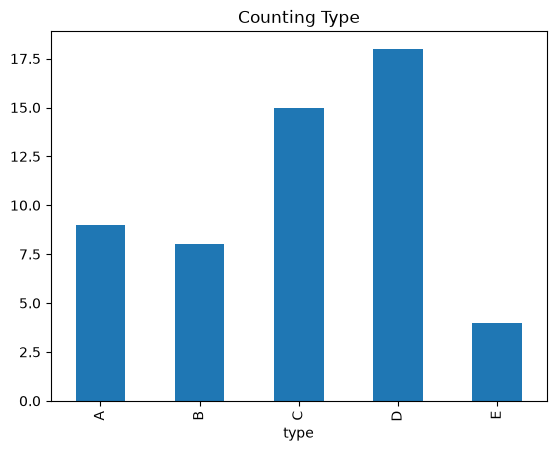

In [25]:
stores['type'].value_counts().sort_index().plot(kind='bar', title='Counting Type')

<Axes: title={'center': 'Counting Cluster'}, xlabel='cluster'>

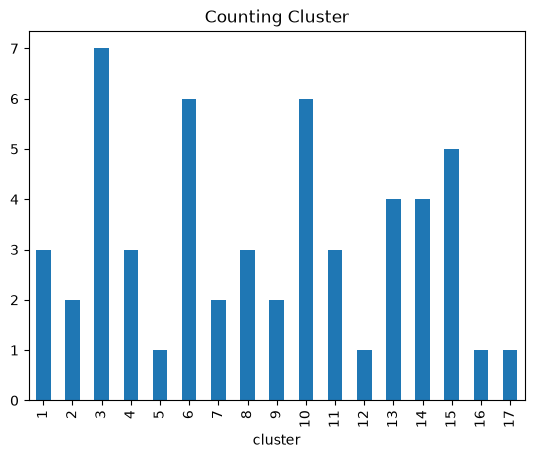

In [26]:
stores['cluster'].value_counts().sort_index().plot(kind='bar', title='Counting Cluster')

In [27]:
pd.crosstab(stores['type'], stores['cluster'])

cluster,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
type,,,,,,,,,,,,,,,,,
A,0,0,0,0,1,0,0,0,0,0,3,0,0,4,0,0,1
B,0,0,0,0,0,6,0,0,0,1,0,0,0,0,0,1,0
C,0,0,7,0,0,0,2,0,0,0,0,1,0,0,5,0,0
D,3,2,0,3,0,0,0,3,2,1,0,0,4,0,0,0,0
E,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0


#### Boxplot 

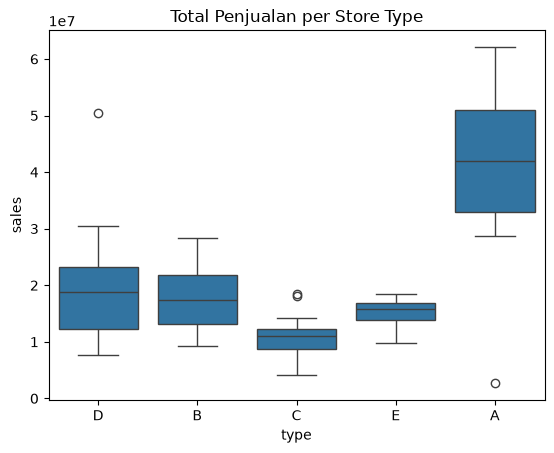

In [28]:
store_total_sales = train.groupby('store_nbr')['sales'].sum().reset_index()
store_total_sales = store_total_sales.merge(stores, on='store_nbr')

sns.boxplot(data=store_total_sales, x='type', y='sales')
plt.title('Total Penjualan per Store Type')
plt.show()

Text(0.5, 1.0, 'Total Penjualan per Store Cluster')

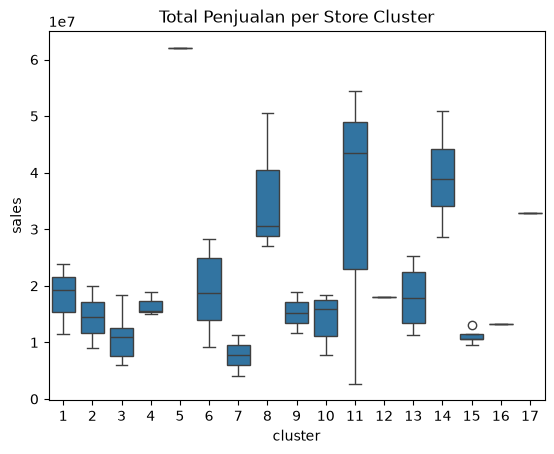

In [29]:
sns.boxplot(data=store_total_sales, x='cluster', y='sales')
plt.title('Total Penjualan per Store Cluster')

In [30]:
pd.crosstab(stores['state'], stores['cluster'])

cluster,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
state,,,,,,,,,,,,,,,,,
Azuay,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
Bolivar,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
Chimborazo,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
Cotopaxi,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0
El Oro,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
Esmeraldas,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
Guayas,2,0,3,0,0,1,0,0,0,4,0,0,0,0,0,0,1
Imbabura,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
Loja,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


### **Analisa Statistik**

In [52]:
sample_per_type = stores.groupby('type', group_keys=False).sample(n=1, random_state=42).reset_index(drop=True)

store_44_row = stores[stores['store_nbr'] == 44]
sample_per_type.loc[sample_per_type['type'] == 'A'] = store_44_row.values[0]

print("=== Sampel 1 toko per tipe: === \n")
display(sample_per_type)


=== Sampel 1 toko per tipe: === 



,store_nbr,city,state,type,cluster
0,44,Quito,Pichincha,A,5
1,21,Santo Domingo,Santo Domingo de los Tsachilas,B,6
2,32,Guayaquil,Guayas,C,3
3,2,Quito,Pichincha,D,13
4,43,Esmeraldas,Esmeraldas,E,10


Dari pengambilan sampel acak dari jenis type di atas disimpulkan bahwa akan digunakan sampel dari masing-masing type  
Type A : **Store 44**  
Type B : **Store 21**  
Type C : **Store 32**  
Type D : **Store 2**  
Type E : **Store 43**  

Akan di analisa lebih lanjut masing-masing store dengan family product : GROCERY I, LAWN AND GARDEN, and HARDWARE

#### $ADI \& CV^2$

In [32]:
store_target = [44, 21, 32, 2, 43]
family_target = ['GROCERY I', 'HARDWARE', 'LAWN AND GARDEN']
sparsity_metrics = []

In [33]:
df_filtered = train[(train['store_nbr'].isin(store_target)) & 
                    (train['family'].isin(family_target))].copy()

df_filtered

,id,date,store_nbr,family,sales,onpromotion
375,375,2013-01-01,2,GROCERY I,0.0,0
377,377,2013-01-01,2,HARDWARE,0.0,0
383,383,2013-01-01,2,LAWN AND GARDEN,0.0,0
441,441,2013-01-01,21,GROCERY I,0.0,0
443,443,2013-01-01,21,HARDWARE,0.0,0
...,...,...,...,...,...,...
3000341,3000341,2017-08-15,43,HARDWARE,0.0,0
3000347,3000347,2017-08-15,43,LAWN AND GARDEN,8.0,2
3000372,3000372,2017-08-15,44,GROCERY I,8123.0,37
3000374,3000374,2017-08-15,44,HARDWARE,2.0,0


In [34]:
daily_sales = df_filtered.groupby(['store_nbr', 'family', 'date'])['sales'].sum().reset_index()

daily_sales

,store_nbr,family,date,sales
0,2,GROCERY I,2013-01-01,0.0
1,2,GROCERY I,2013-01-02,3870.0
2,2,GROCERY I,2013-01-03,2640.0
3,2,GROCERY I,2013-01-04,2697.0
4,2,GROCERY I,2013-01-05,3545.0
...,...,...,...,...
25255,44,LAWN AND GARDEN,2017-08-11,49.0
25256,44,LAWN AND GARDEN,2017-08-12,37.0
25257,44,LAWN AND GARDEN,2017-08-13,28.0
25258,44,LAWN AND GARDEN,2017-08-14,18.0


Berikut ini akan dilakukan uji $ADI$ (Average Demand Interval) dan $CV^2$ (Squared Coefficient of Variation) untuk mengetahui pengelompokkan jenis dari time series yang sedang kita hadapi. Pada kasus ini terdapat 4 klasifikasi utama yaitu  

1. **Smooth Demand** $(ADI < 1.32, CV^2 < 0.49)$  : Berikut merupakan jenis permintaan yang sangat biasa dalam waktu dan kuantitas permintaan. Sehingga dapat di prediksi dengan lebih mudah dan galat relatif akan tidak terlalu besar.
2. **Intermittent Demand** $(ADI >= 1.32, CV^2 < 0.49)$ : Berikut jenis permintaan yang dalam satuan kuantitas permintaan variasinya biasa (tidak terlalu berbeda) namun dalam satuan waktu variasinya relatif lebih besar. 
3. **Erratic Demand** $(ADI < 1.32, CV^2 >= 0.49)$ : Pada klasifikasi ini satuan waktu variasinya relatif lebih biasa (tidak terlalu jauh), namun dalam satuan permintaan variasinya relatif lebih besar.
4. **Lumpy Demand** $(ADI >= 1.32, CV^2 >= 0.49)$ : Terakhir pada klasifikasi ini kedua satuan sama sama memiliki variasi yang besar sehingga sangat sulit untuk di prediksi.

In [35]:
for store in store_target:
    for family in family_target:
        df_family = daily_sales[(daily_sales['store_nbr'] == store) & 
                                (daily_sales['family'] == family)]

        non_zero_sales = df_family[df_family['sales'] > 0]['sales']

        total_periods = len(df_family)
        non_zero_periods = len(non_zero_sales)

        if non_zero_periods == 0:
            continue

        adi = total_periods / non_zero_periods

        if non_zero_periods > 1:
            cv2 = (non_zero_sales.std() / non_zero_sales.mean()) ** 2
        else :
            cv2 = 0
        
        if adi < 1.32 and cv2 < 0.49:
            category = 'Smooth'
        elif adi >= 1.32 and cv2 < 0.49:
            category = 'Intermittent'
        elif adi < 1.32 and cv2 >= 0.49:
            category = 'Erratic'
        else :
            category = 'Lumpy'
        
        sparsity_metrics.append({
            'Store': store,
            'Family': family,
            'ADI': adi,
            'CV2': cv2,
            'Category': category,
            'Zero_Sales_Ratio(%)': ((total_periods - non_zero_periods) / total_periods) * 100
        })

In [44]:
df_sparsity = pd.DataFrame(sparsity_metrics)
print('\n=== Hasil Metrik Sparsitas ===')
display(df_sparsity.round(3))


=== Hasil Metrik Sparsitas ===


,Store,Family,ADI,CV2,Category,Zero_Sales_Ratio(%)
0,44,GROCERY I,1.003,0.132,Smooth,0.297
1,44,HARDWARE,1.084,0.494,Erratic,7.779
2,44,LAWN AND GARDEN,1.037,0.853,Erratic,3.563
3,21,GROCERY I,2.245,0.158,Intermittent,55.463
4,21,HARDWARE,4.048,0.395,Intermittent,75.297
5,21,LAWN AND GARDEN,3.062,2.615,Lumpy,67.340
6,32,GROCERY I,1.003,0.384,Smooth,0.297
7,32,HARDWARE,2.934,0.295,Intermittent,65.914
8,32,LAWN AND GARDEN,336.800,0.216,Intermittent,99.703
9,2,GROCERY I,1.004,0.834,Erratic,0.356


In [37]:
df_sparsity['Category'].value_counts()

Category
Intermittent    5
Erratic         4
Smooth          3
Lumpy           3
Name: count, dtype: int64

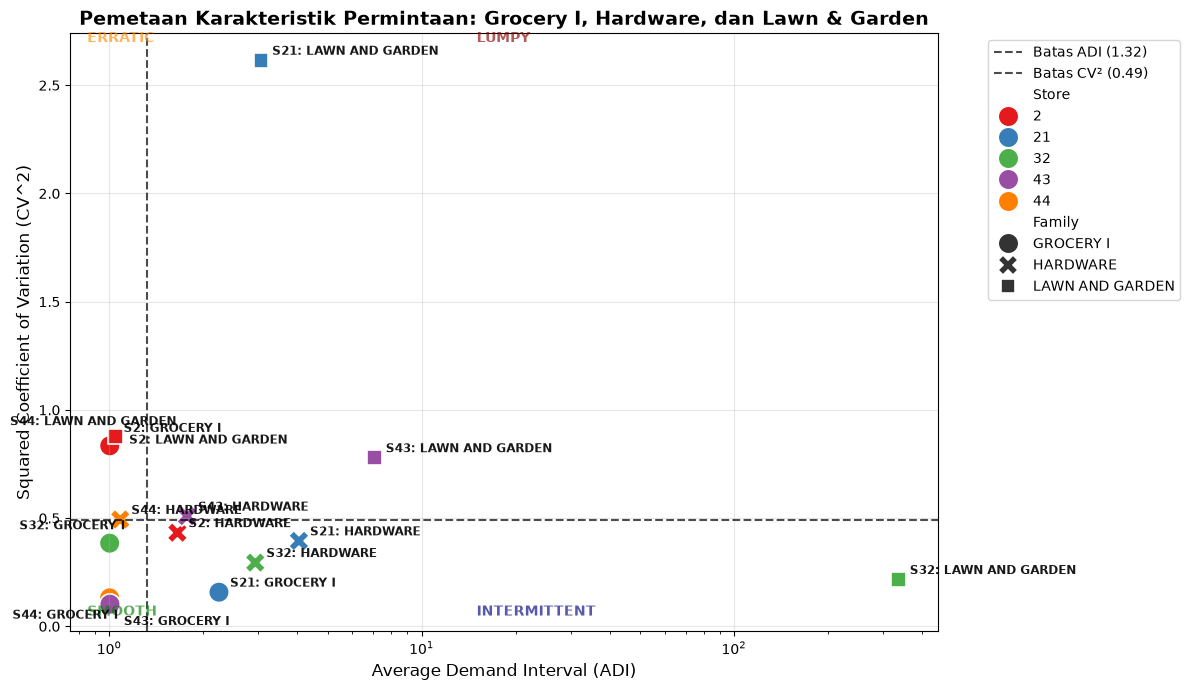

In [38]:
plt.figure(figsize=(12, 7))
ax = plt.gca()

plt.axvline(x=1.32, color='black', linestyle='--', alpha=0.7, linewidth=1.5, label='Batas ADI (1.32)')
plt.axhline(y=0.49, color='black', linestyle='--', alpha=0.7, linewidth=1.5, label='Batas CV² (0.49)')

plt.xscale('log')

plt.text(0.85, 0.05, 'SMOOTH', fontsize=10, color='green', fontweight='bold', alpha=0.65)
plt.text(0.85, 2.7, 'ERRATIC', fontsize=10, color='darkorange', fontweight='bold', alpha=0.65)
plt.text(15, 0.05, 'INTERMITTENT', fontsize=10, color='navy', fontweight='bold', alpha=0.65)
plt.text(15, 2.7, 'LUMPY', fontsize=10, color='darkred', fontweight='bold', alpha=0.65)

sns.scatterplot(
    x='ADI', y='CV2',
    hue='Store', 
    style='Family',
    data=df_sparsity,
    s=220,
    palette='Set1',
)

offsets = {
    (44, 'LAWN AND GARDEN'): (-75, 12),
    (2, 'LAWN AND GARDEN'): (10, -5),
    (44, 'GROCERY I'): (-70, -15),
    (43, 'GROCERY I'): (10, -15),
    (32, 'GROCERY I'): (-65, 10),
    (2, 'GROCERY I'): (10, 10),
}

for _, row in df_sparsity.iterrows():
    key = (row['Store'], row['Family'])
    offset = offsets.get(key, (8, 4))
    
    ax.annotate(
        f"S{int(row['Store'])}: {row['Family']}",
        (row['ADI'], row['CV2']),
        xytext=offset, 
        textcoords='offset points',
        fontsize=8.5, fontweight='bold', alpha=0.9
    )


plt.title('Pemetaan Karakteristik Permintaan: Grocery I, Hardware, dan Lawn & Garden', fontsize=14, fontweight='bold')
plt.xlabel('Average Demand Interval (ADI)', fontsize=12)
plt.ylabel('Squared Coefficient of Variation (CV^2)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

#### Uji Statistik ADF (Augmented Dickey-Fuller)  
$$ H_0 = \text{Deret tersebut memiliki unit akar (tidak stasioner)} \\ 
H_1 = \text{Deret stasioner} $$

In [43]:
adf_results = []

for (store, family), group in daily_sales.groupby(['store_nbr', 'family']):
    sales_series = group['sales'].dropna().values
    
    result = adfuller(sales_series, autolag='AIC')
    adf_stat = result[0]
    p_value = result[1]
    crit_values = result[4]
    
    status = 'Stasioner' if p_value < 0.05 else 'Tidak Stasioner'
    
    adf_results.append({
        'Store': store,
        'Family': family,
        'ADF Statistic': adf_stat,
        'p-value': p_value,
        'Kritis 5%': crit_values['5%'],
        'Status': status
    })

df_adf = pd.DataFrame(adf_results)
print('=== Hasil Uji Statistik ADF (Augmented Dickey-Fuller) ===')
display(df_adf.round(4))

print('\n=== Ringkasan Kestationeran (alpha = 0.05) ===')
print(df_adf['Status'].value_counts())


=== Hasil Uji Statistik ADF (Augmented Dickey-Fuller) ===


,Store,Family,ADF Statistic,p-value,Kritis 5%,Status
0,2,GROCERY I,-7.1705,0.0000,-2.8633,Stasioner
1,2,HARDWARE,-7.0873,0.0000,-2.8633,Stasioner
2,2,LAWN AND GARDEN,-2.6070,0.0916,-2.8633,Tidak Stasioner
3,21,GROCERY I,-1.5399,0.5137,-2.8633,Tidak Stasioner
4,21,HARDWARE,-3.0232,0.0328,-2.8633,Stasioner
5,21,LAWN AND GARDEN,-6.9178,0.0000,-2.8633,Stasioner
6,32,GROCERY I,-4.5103,0.0002,-2.8633,Stasioner
7,32,HARDWARE,-10.7252,0.0000,-2.8633,Stasioner
8,32,LAWN AND GARDEN,-7.9999,0.0000,-2.8633,Stasioner
9,43,GROCERY I,-2.6453,0.0840,-2.8633,Tidak Stasioner



=== Ringkasan Kestationeran (alpha = 0.05) ===
Status
Stasioner          10
Tidak Stasioner     5
Name: count, dtype: int64


#### Uji Kruskal Wallis  
Apakah terdapat perbedaan yang signifikan antara ADI dan CV^2 dari masing masing toko dan family produk?

### Preprocessing Data

### Membangun Arsitektur LSTM